In [1]:
import os

import numpy as np
import pandas  as pd

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)




In [2]:
DATA_DIR = "../data"
FIGURE_DIR = "../outputs/figures"

TRAIN_PATH = os.path.join(DATA_DIR, "train.csv")
TEST_PATH = os.path.join(DATA_DIR, "test.csv")
SAMPLE_SUBMISSION_PATH = os.path.join(DATA_DIR, "sample_submission.csv")

os.makedirs(FIGURE_DIR, exist_ok=True)

In [3]:
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)
sample_submission_df = pd.read_csv(SAMPLE_SUBMISSION_PATH)

In [4]:
print(type(train_df))
print(type(test_df))
print(type(sample_submission_df))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>


In [5]:
train_df.head()

,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY


In [6]:
train_df.tail()

,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
577342,577342,223.539288,2.503680,20.828729,18.854201,17.703108,17.190536,16.551356,0.511524,M,Red_Sequence,GALAXY
577343,577343,223.895970,40.769343,23.734743,22.359173,20.697865,19.180264,18.947275,0.658589,M,Red_Sequence,GALAXY
577344,577344,52.258927,0.671887,21.944250,21.215856,19.025966,18.772276,18.203397,0.376342,M,Red_Sequence,GALAXY
577345,577345,247.362248,50.659819,21.969881,21.622766,20.987575,20.930924,21.478134,2.868359,G/K,Blue_Cloud,QSO
577346,577346,194.633820,-1.307079,21.244353,21.101997,20.809379,20.866345,20.495411,1.101004,A/F,Blue_Cloud,QSO


In [28]:
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Sample submission shape:", sample_submission_df.shape)

Train shape: (577347, 12)
Test shape: (247435, 11)
Sample submission shape: (247435, 2)


In [9]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577347 entries, 0 to 577346
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 577347 non-null  int64  
 1   alpha              577347 non-null  float64
 2   delta              577347 non-null  float64
 3   u                  577347 non-null  float64
 4   g                  577347 non-null  float64
 5   r                  577347 non-null  float64
 6   i                  577347 non-null  float64
 7   z                  577347 non-null  float64
 8   redshift           577347 non-null  float64
 9   spectral_type      577347 non-null  object 
 10  galaxy_population  577347 non-null  object 
 11  class              577347 non-null  object 
dtypes: float64(8), int64(1), object(3)
memory usage: 52.9+ MB


In [10]:
missing_values = train_df.isnull().sum()
missing_percentage = train_df.isnull().sum() * 100 / train_df.shape[0]

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": missing_percentage
})

missing_summary

,Missing Values,Missing Percentage
id,0,0.0
alpha,0,0.0
delta,0,0.0
u,0,0.0
g,0,0.0
r,0,0.0
i,0,0.0
z,0,0.0
redshift,0,0.0
spectral_type,0,0.0


In [11]:
print("Duplicate rows in train:", train_df.duplicated().sum())
print("Duplicate rows in test:", test_df.duplicated().sum())

Duplicate rows in train: 0
Duplicate rows in test: 0


In [12]:
train_df.describe()

,id,alpha,delta,u,g,r,i,z,redshift
count,577347.00000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000
mean,288673.00000,181.616673,21.834654,22.441926,21.007273,19.962811,19.378911,19.041136,0.723135
std,166665.86727,96.242941,18.933570,2.018135,1.795426,1.648964,1.580059,1.584365,0.810070
min,0.00000,0.011684,-17.966988,-0.139225,13.535483,12.579407,11.962781,11.682803,-0.009970
25%,144336.50000,132.161499,2.474097,20.977090,19.865005,18.820671,18.306820,17.973192,0.181052
50%,288673.00000,188.681465,21.484412,22.570222,21.467820,20.431153,19.631642,19.188598,0.497525
75%,433009.50000,231.829693,36.988310,23.869103,22.292715,21.164096,20.608191,20.162111,0.881390
max,577346.00000,359.999810,79.158322,28.253263,27.620208,25.254499,27.910853,26.826867,7.010780


In [13]:
class_counts = train_df["class"].value_counts()
class_percentages = train_df["class"].value_counts(normalize=True) * 100

class_distribution = pd.DataFrame({
    "Count": class_counts,
    "Percentage": class_percentages.round(2)
})

class_distribution

,Count,Percentage
class,,
GALAXY,377480,65.38
QSO,117143,20.29
STAR,82724,14.33


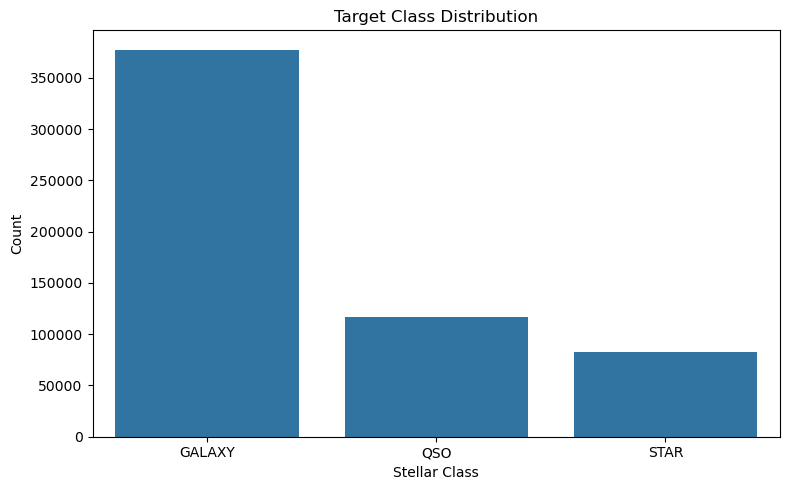

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=train_df, x="class", order=train_df["class"].value_counts().index)
plt.title("Target Class Distribution")
plt.xlabel("Stellar Class")
plt.ylabel("Count")
plt.tight_layout()

plt.savefig(os.path.join(
    , "target_class_distribution.png"), dpi=300)
plt.show()

In [15]:
categorical_columns = ["spectral_type", "galaxy_population", "class"]

for col in categorical_columns:
    print(f"\nColumn: {col}")
    print(train_df[col].value_counts())


Column: spectral_type
spectral_type
M      303323
A/F    122122
G/K    108546
O/B     43356
Name: count, dtype: int64

Column: galaxy_population
galaxy_population
Red_Sequence    319565
Blue_Cloud      257782
Name: count, dtype: int64

Column: class
class
GALAXY    377480
QSO       117143
STAR       82724
Name: count, dtype: int64


In [16]:
numeric_columns = train_df.select_dtypes(include=["int64", "float64"]).columns.tolist()

print(numeric_columns)

['id', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']


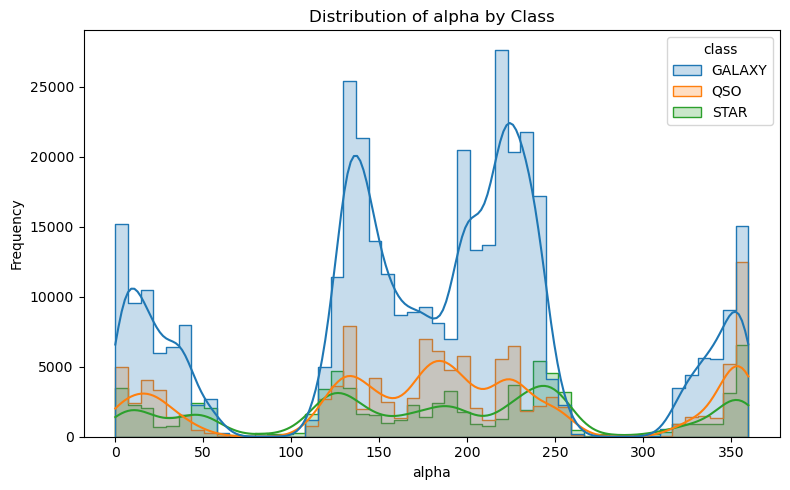

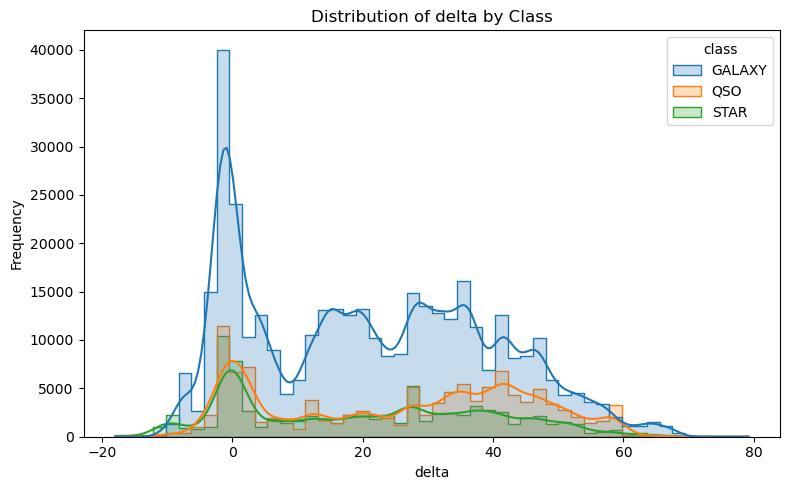

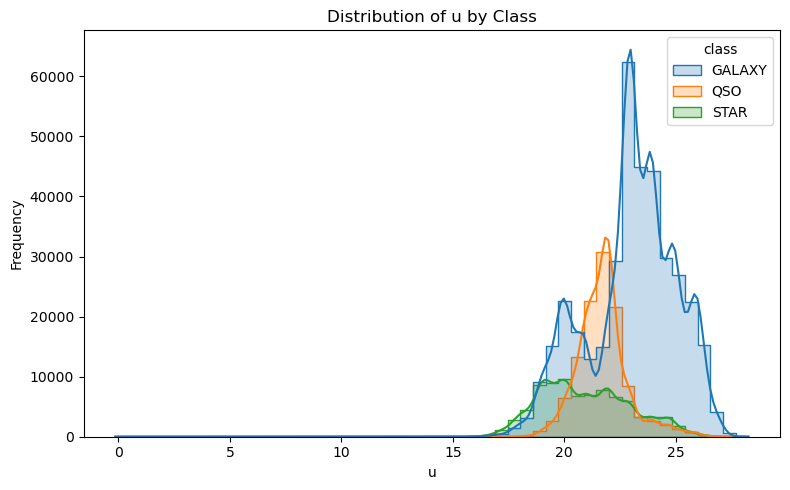

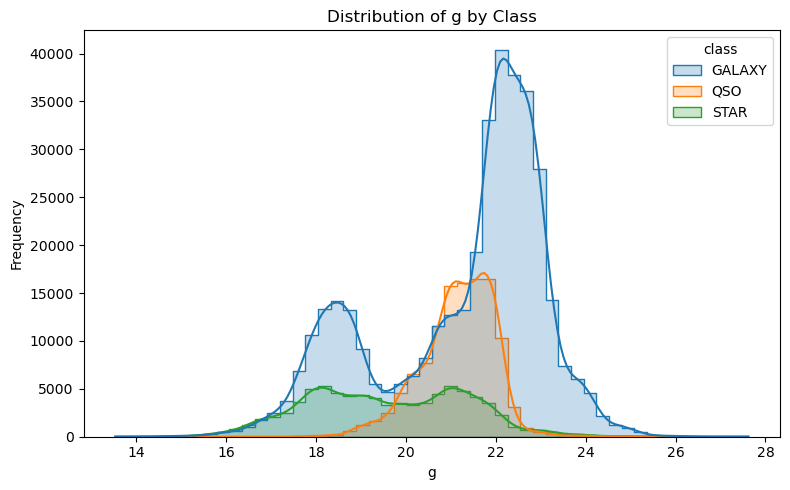

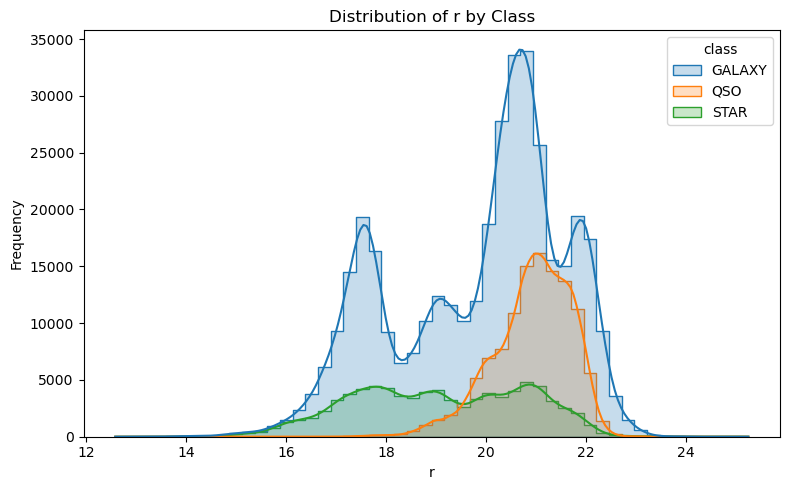

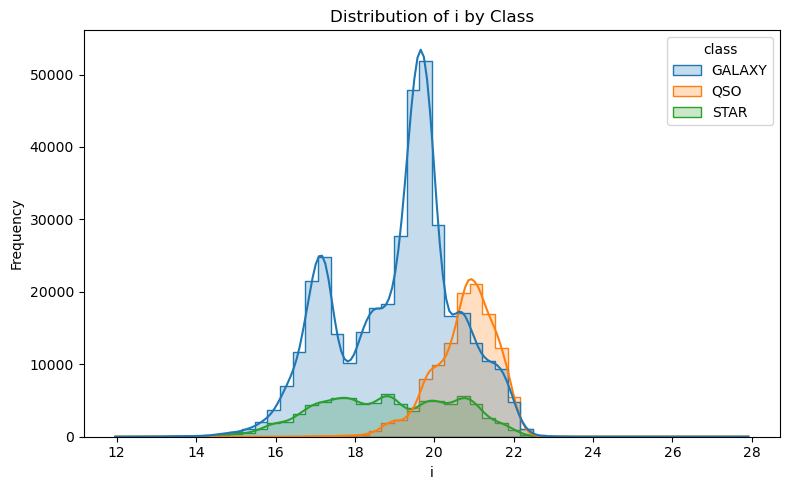

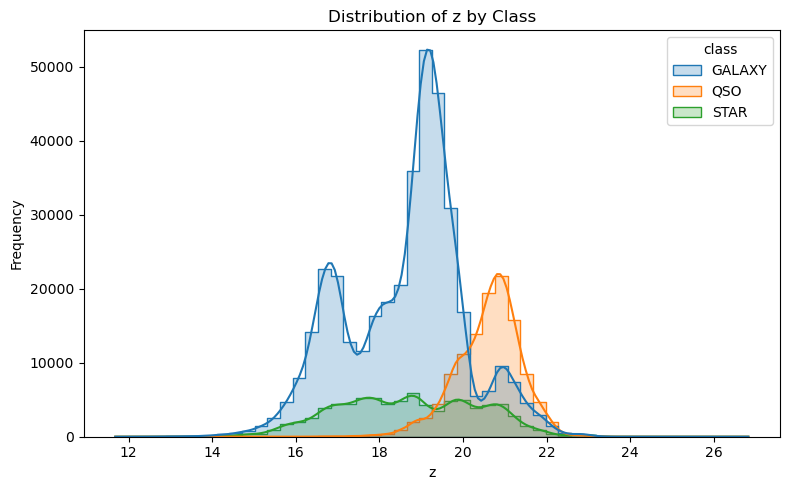

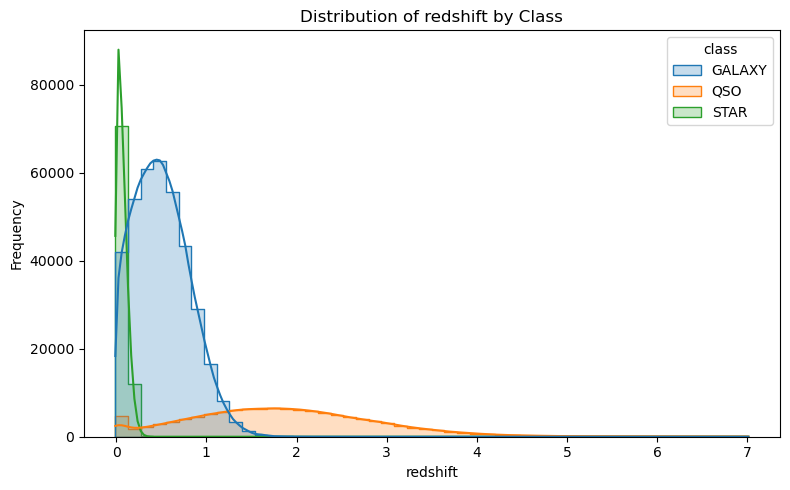

In [17]:
features_to_plot = ["alpha", "delta", "u", "g", "r", "i", "z", "redshift"]

for col in features_to_plot:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=train_df, x=col, hue="class", bins=50, kde=True, element="step")
    plt.title(f"Distribution of {col} by Class")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    
    plt.savefig(os.path.join(FIGURE_DIR, f"distribution_{col}.png"), dpi=300)
    plt.show()

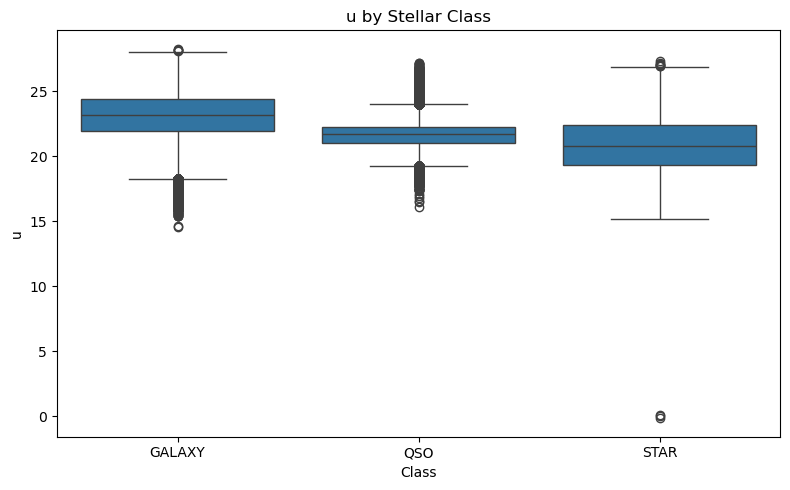

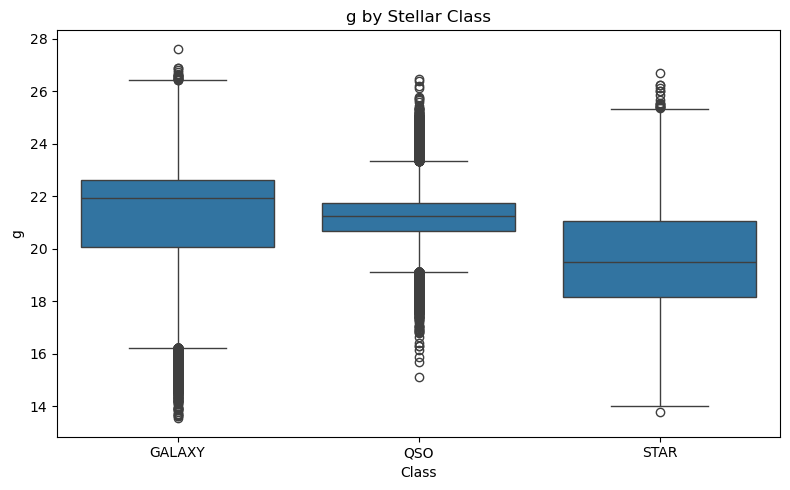

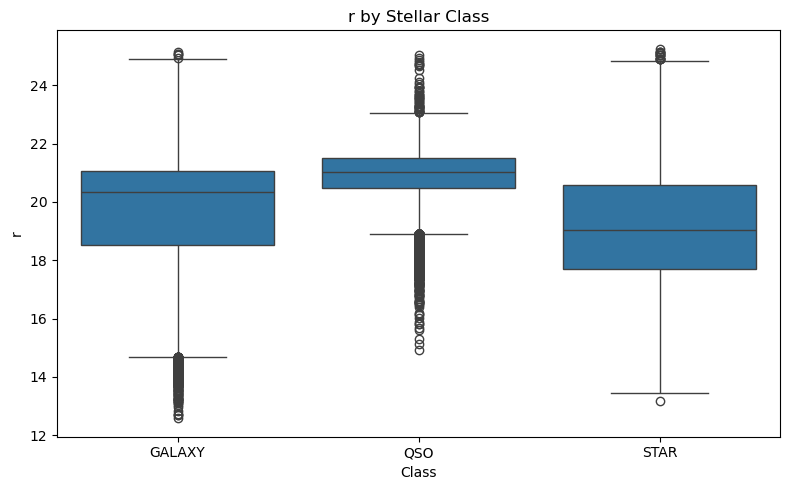

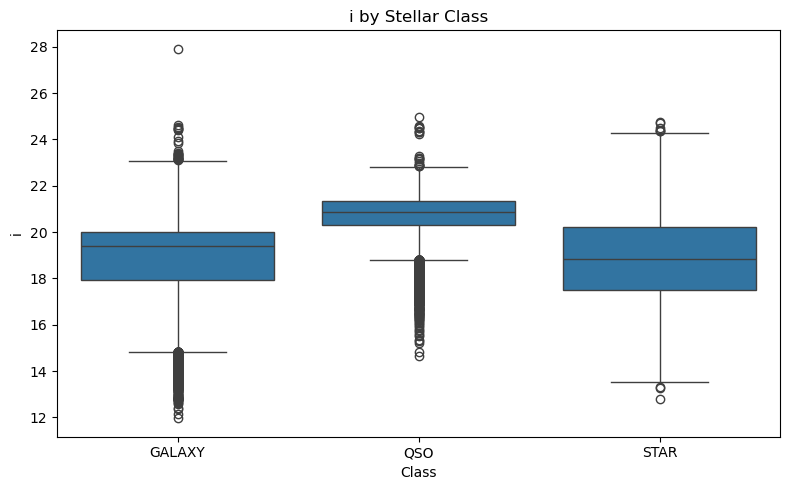

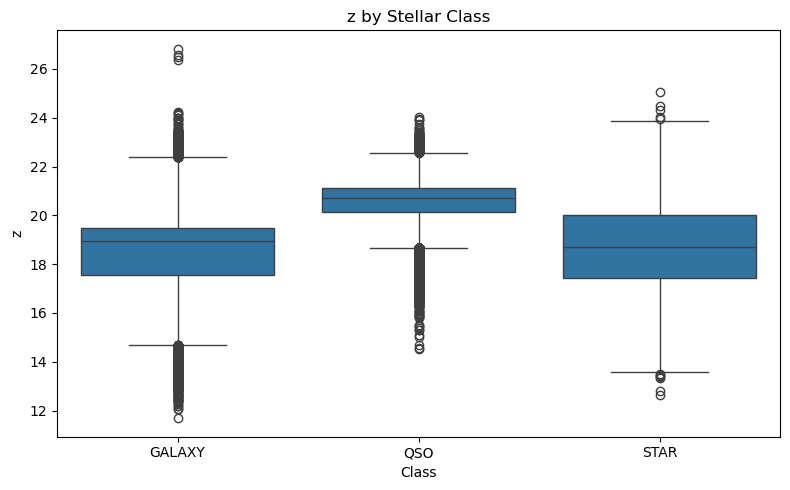

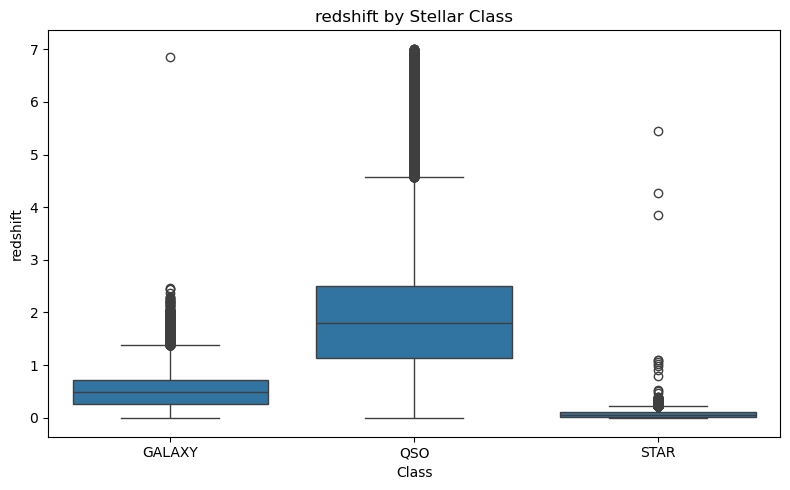

In [18]:
for col in ["u", "g", "r", "i", "z", "redshift"]:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=train_df, x="class", y=col)
    plt.title(f"{col} by Stellar Class")
    plt.xlabel("Class")
    plt.ylabel(col)
    plt.tight_layout()
    
    plt.savefig(os.path.join(FIGURE_DIR, f"boxplot_{col}_by_class.png"), dpi=300)
    plt.show()

In [19]:
eda_df = train_df.copy()

eda_df["u_g"] = eda_df["u"] - eda_df["g"]
eda_df["g_r"] = eda_df["g"] - eda_df["r"]
eda_df["r_i"] = eda_df["r"] - eda_df["i"]
eda_df["i_z"] = eda_df["i"] - eda_df["z"]
eda_df["u_r"] = eda_df["u"] - eda_df["r"]
eda_df["g_i"] = eda_df["g"] - eda_df["i"]

eda_df.head()

,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class,u_g,g_r,r_i,i_z,u_r,g_i
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY,3.576564,1.537632,1.100813,0.636056,5.114196,2.638446
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY,1.691447,1.499854,0.361141,0.439634,3.191300,1.860995
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO,-0.043925,-0.092712,0.589211,0.025263,-0.136637,0.496499
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY,2.254320,2.032982,0.652096,0.450706,4.287302,2.685077
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY,2.231478,1.237231,0.335002,0.283262,3.468709,1.572233


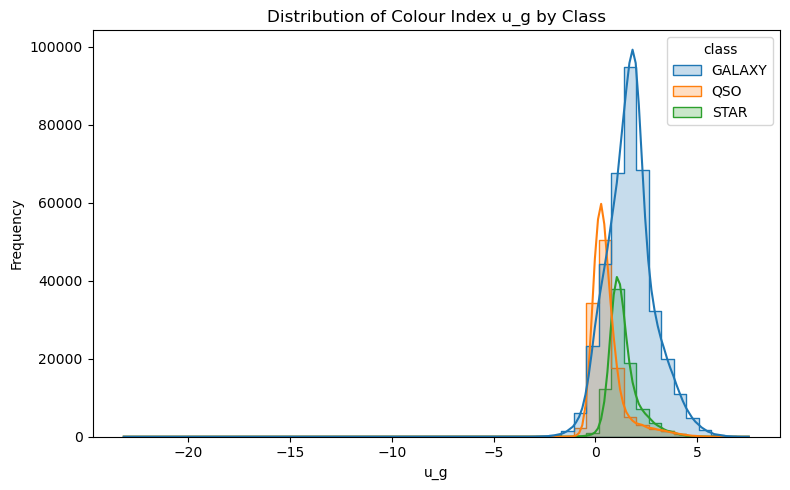

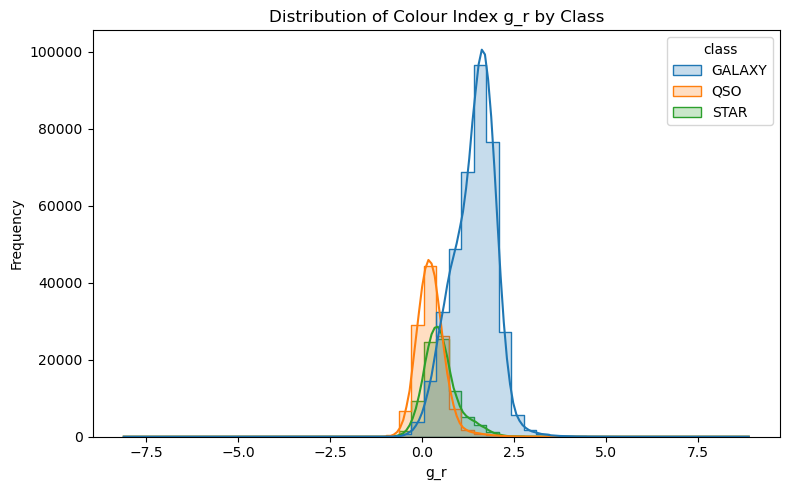

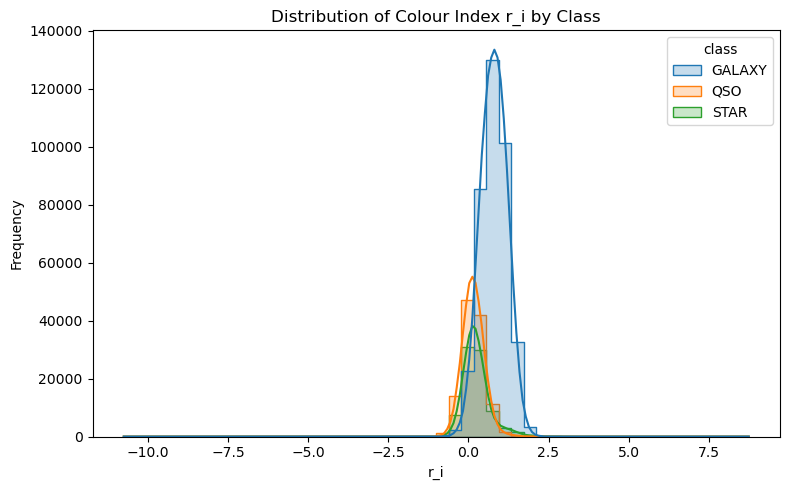

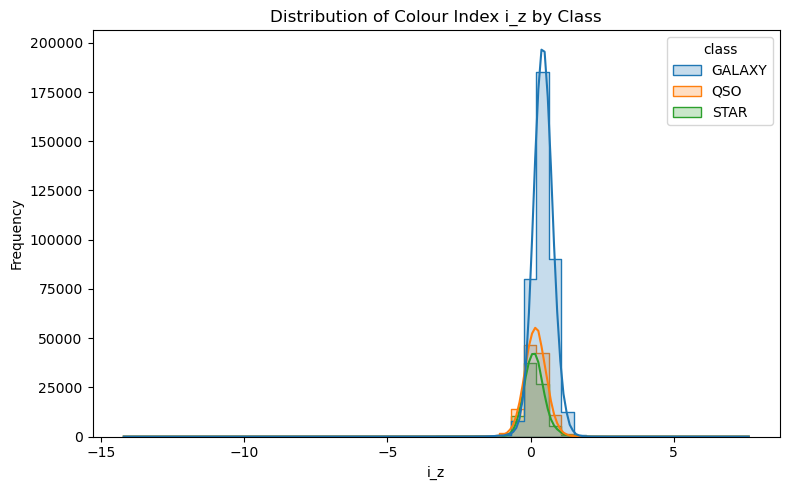

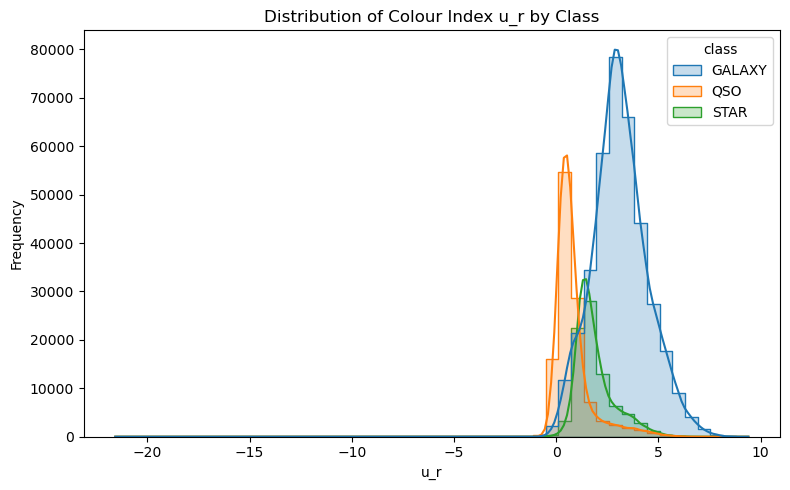

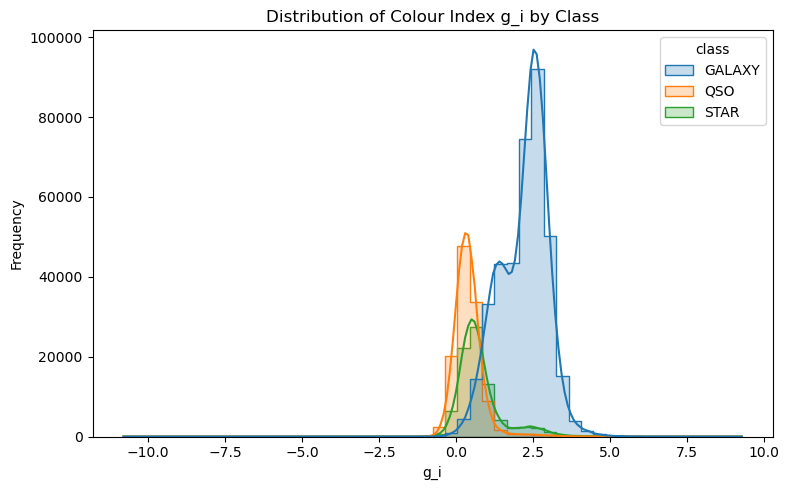

In [20]:
colour_features = ["u_g", "g_r", "r_i", "i_z", "u_r", "g_i"]

for col in colour_features:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=eda_df, x=col, hue="class", bins=50, kde=True, element="step")
    plt.title(f"Distribution of Colour Index {col} by Class")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    
    plt.savefig(os.path.join(FIGURE_DIR, f"colour_index_{col}.png"), dpi=300)
    plt.show()

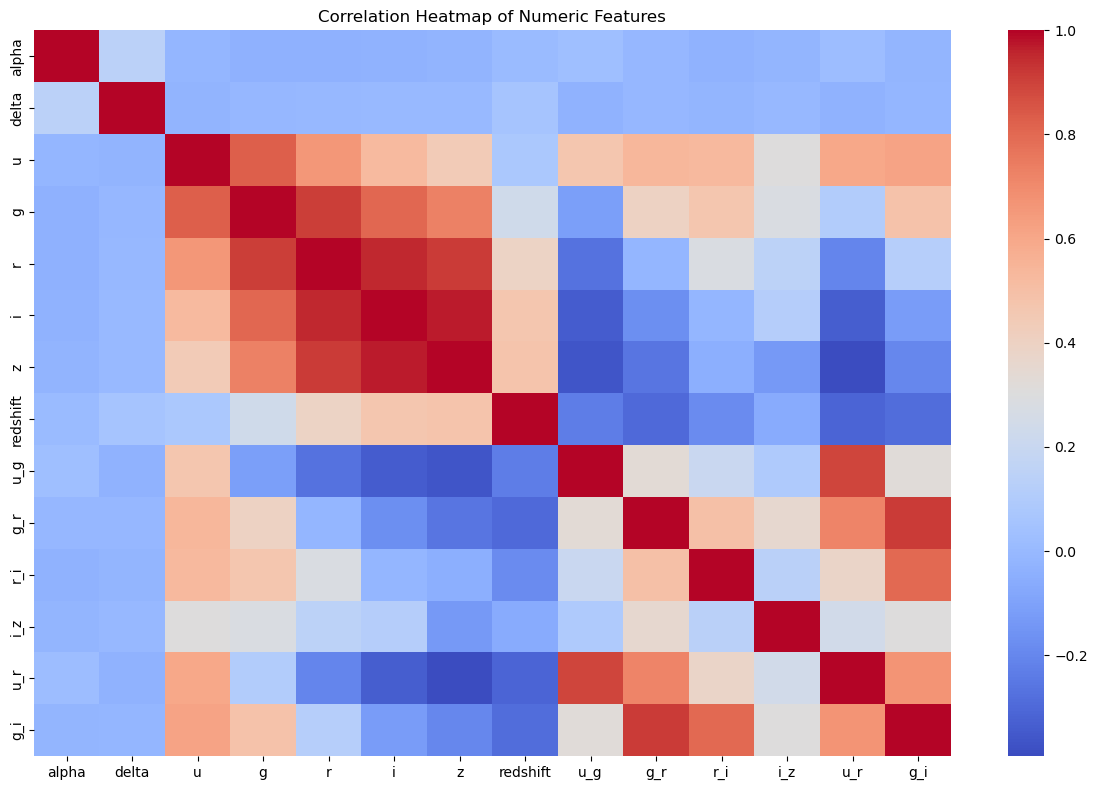

In [21]:
corr_columns = [
    "alpha", "delta", "u", "g", "r", "i", "z", "redshift",
    "u_g", "g_r", "r_i", "i_z", "u_r", "g_i"
]

correlation_matrix = eda_df[corr_columns].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()

plt.savefig(os.path.join(FIGURE_DIR, "correlation_heatmap.png"), dpi=300)
plt.show()

In [22]:
spectral_class_table = pd.crosstab(
    train_df["spectral_type"],
    train_df["class"],
    normalize="index"
) * 100

spectral_class_table.round(2)

class,GALAXY,QSO,STAR
spectral_type,,,
A/F,19.85,50.37,29.78
G/K,56.78,19.27,23.95
M,94.96,1.28,3.76
O/B,8.28,71.08,20.64


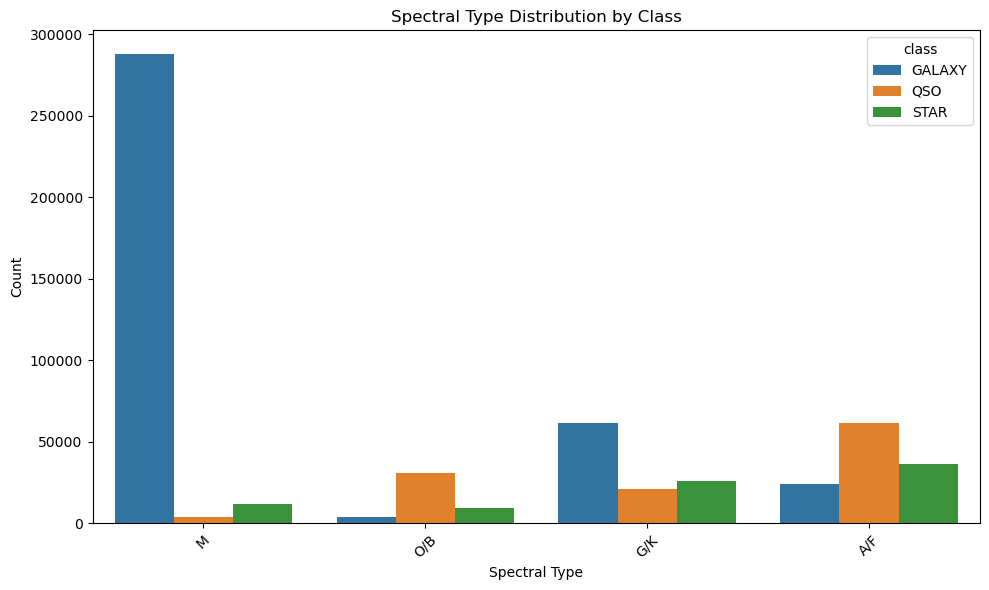

In [23]:
plt.figure(figsize=(10, 6))
sns.countplot(data=train_df, x="spectral_type", hue="class")
plt.title("Spectral Type Distribution by Class")
plt.xlabel("Spectral Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(os.path.join(FIGURE_DIR, "spectral_type_by_class.png"), dpi=300)
plt.show()

In [24]:
population_class_table = pd.crosstab(
    train_df["galaxy_population"],
    train_df["class"],
    normalize="index"
) * 100

population_class_table.round(2)

class,GALAXY,QSO,STAR
galaxy_population,,,
Blue_Cloud,34.51,42.00,23.49
Red_Sequence,90.28,2.78,6.94


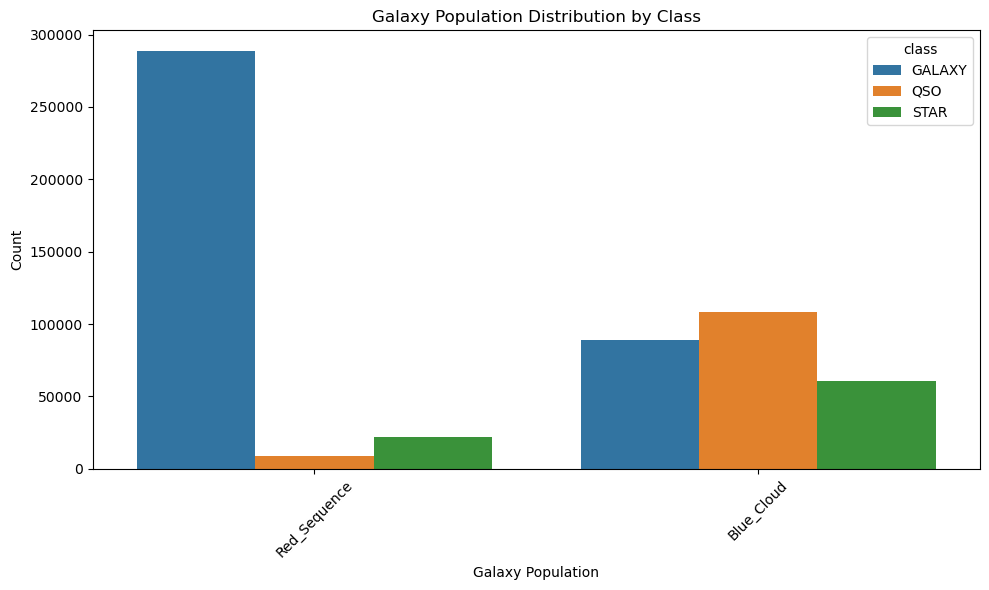

In [25]:
plt.figure(figsize=(10, 6))
sns.countplot(data=train_df, x="galaxy_population", hue="class")
plt.title("Galaxy Population Distribution by Class")
plt.xlabel("Galaxy Population")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(os.path.join(FIGURE_DIR, "galaxy_population_by_class.png"), dpi=300)
plt.show()

In [26]:
sample_submission_df.head()

,id,class
0,577347,GALAXY
1,577348,GALAXY
2,577349,GALAXY
3,577350,GALAXY
4,577351,GALAXY
